# Exploratory Data Analysis (EDA)
## Project: Online Payment Fraud Detection
> This notebook contain exploratory data analysis for Online Payment Fraud Detection project
- Exploratory Data Analysis on the cleaned dataset.
- Understand data distribution, relationship between features and their impact on dataset.
### The purpose of EDA is to: 
- The EDA process involv examine the dataset to understand it's structure identify patterns and detect any anamolies or missing values.
- Analyze relationship between features and the target variable.
- This step is crucial for preparing the data for modeling and ensuring that the insights derived from the data's are accurate and meaningful.
> Note: No data Transformation, Encoding, or Scaling is performed in this step.

## Import Libraries

In [ ]:
#---- Data manipulation -----------------------
import numpy as np
import pandas as pd

#---- Visualization --------------------------
import matplotlib.pyplot as plt 
import seaborn as sns

#---- Plot Settings -------------------------
sns.set_theme(style = "whitegrid", palette = "muted")
plt.rcParams["figure.figsize"] = (10, 5)

#---- For Warnings ---------------------------
import warnings
warnings.filterwarnings("ignore")

## Load Cleaned Dataset

In [3]:
#---- Load the cleaned dataset -----------------------
df = pd.read_csv(r"D:\Portfolio\Online_Payment_Fraud_Detection\data\cleaned_data.csv")

#---- Quick Overview --------------------------------
print(f"Shape: {df.shape}")
df.head()

Shape: (99887, 18)


,transaction_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,payment_channel,device_type,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
0,305461,1417,4,2,7549.746993,0.056340,1783.564199,card,mobile,0,0.417366,1,2,0,54.226534,1531.905966,0,0.358507
1,341279,830,2,2,2766.322082,0.736960,7038.755549,card,mobile,0,0.272247,1,3,1,60.728405,6946.544813,0,0.065886
2,344364,1651,2,3,3988.151593,0.454618,663.057016,upi,mobile,0,0.446442,3,3,0,102.171038,530.118629,0,0.026225
3,84227,1207,1,2,5472.122178,0.417973,1665.509484,card,desktop,0,0.308703,2,3,0,10.146806,1483.105412,0,0.201940
4,187825,1926,5,2,1758.784635,0.535169,1524.306346,card,mobile,1,0.305401,2,1,1,18.328551,1465.680191,0,0.234395


## Dataset Overview

In [4]:
#---- Data types and basic info --------------------
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99887 entries, 0 to 99886
Data columns (total 18 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   transaction_id                   99887 non-null  int64  
 1   account_age_days                 99887 non-null  int64  
 2   credit_score_band                99887 non-null  int64  
 3   kyc_level                        99887 non-null  int64  
 4   avg_monthly_spend                99887 non-null  float64
 5   merchant_risk_score              99887 non-null  float64
 6   transaction_amount               99887 non-null  float64
 7   payment_channel                  99887 non-null  object 
 8   device_type                      99887 non-null  object 
 9   is_international                 99887 non-null  int64  
 10  ip_risk_score                    99887 non-null  float64
 11  txn_count_1h                     99887 non-null  int64  
 12  txn_count_24h     

In [ ]:
#---- Statistical Summary -------------------------
df.describe()

,transaction_id,account_age_days,credit_score_band,kyc_level,avg_monthly_spend,merchant_risk_score,transaction_amount,is_international,ip_risk_score,txn_count_1h,txn_count_24h,failed_txn_count_24h,geo_distance_from_last_txn,amount_deviation_from_user_mean,is_fraud,post_auth_risk_score
count,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000,99887.000000
mean,199766.074885,1015.371770,3.001952,2.000861,5010.227368,0.251144,2402.424634,0.070500,0.286149,1.098571,3.193569,0.350396,34.102134,2235.417055,0.019852,0.212751
std,115390.859545,571.352939,1.411934,0.817754,3156.631432,0.146128,1700.928317,0.255989,0.159996,1.047610,1.784554,0.591879,25.616841,1704.310718,0.139494,0.146650
min,0.000000,30.000000,1.000000,1.000000,43.855387,0.001365,2.582327,0.000000,0.001049,0.000000,0.000000,0.000000,0.000844,-591.254461,0.000000,0.000001
25%,99975.500000,519.000000,2.000000,1.000000,2681.766985,0.136277,1156.397497,0.000000,0.160760,0.000000,2.000000,0.000000,13.740519,988.724336,0.000000,0.101666
50%,200061.000000,1015.000000,3.000000,2.000000,4354.933259,0.229436,2013.834825,0.000000,0.265013,1.000000,3.000000,0.000000,28.939060,1850.656646,0.000000,0.203705
75%,299469.000000,1511.000000,4.000000,3.000000,6684.831846,0.344912,3229.179596,0.000000,0.390788,2.000000,4.000000,1.000000,49.138707,3065.073793,0.000000,0.306216
max,399999.000000,1999.000000,5.000000,3.000000,32362.617533,0.837624,16726.789145,1.000000,0.944763,9.000000,13.000000,6.000000,180.819053,16148.411469,1.000000,0.999988


## Target Variable Analysis (Class Distribution)
> How many fraud vs legitimate transactions?

In [6]:
#---- Count of fraud vs legit --------------------------
fraud_counts = df["is_fraud"].value_counts()
fraud_pct = df["is_fraud"].value_counts(normalize = True) * 100

print(fraud_counts)
print(fraud_pct.round(2))

is_fraud
0    97904
1     1983
Name: count, dtype: int64
is_fraud
0    98.01
1     1.99
Name: proportion, dtype: float64


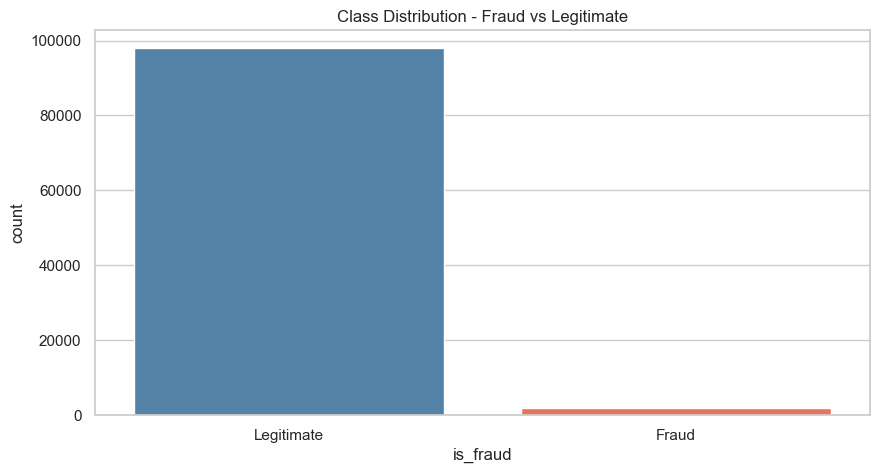

In [7]:
#---- Plot ---------------------------------------------------------
sns.countplot(x="is_fraud", data = df, palette = ["steelblue", "tomato"])
plt.title("Class Distribution - Fraud vs Legitimate")
plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.show()

## Numerical Features Distribution
> Understanding the spread of each numerical column

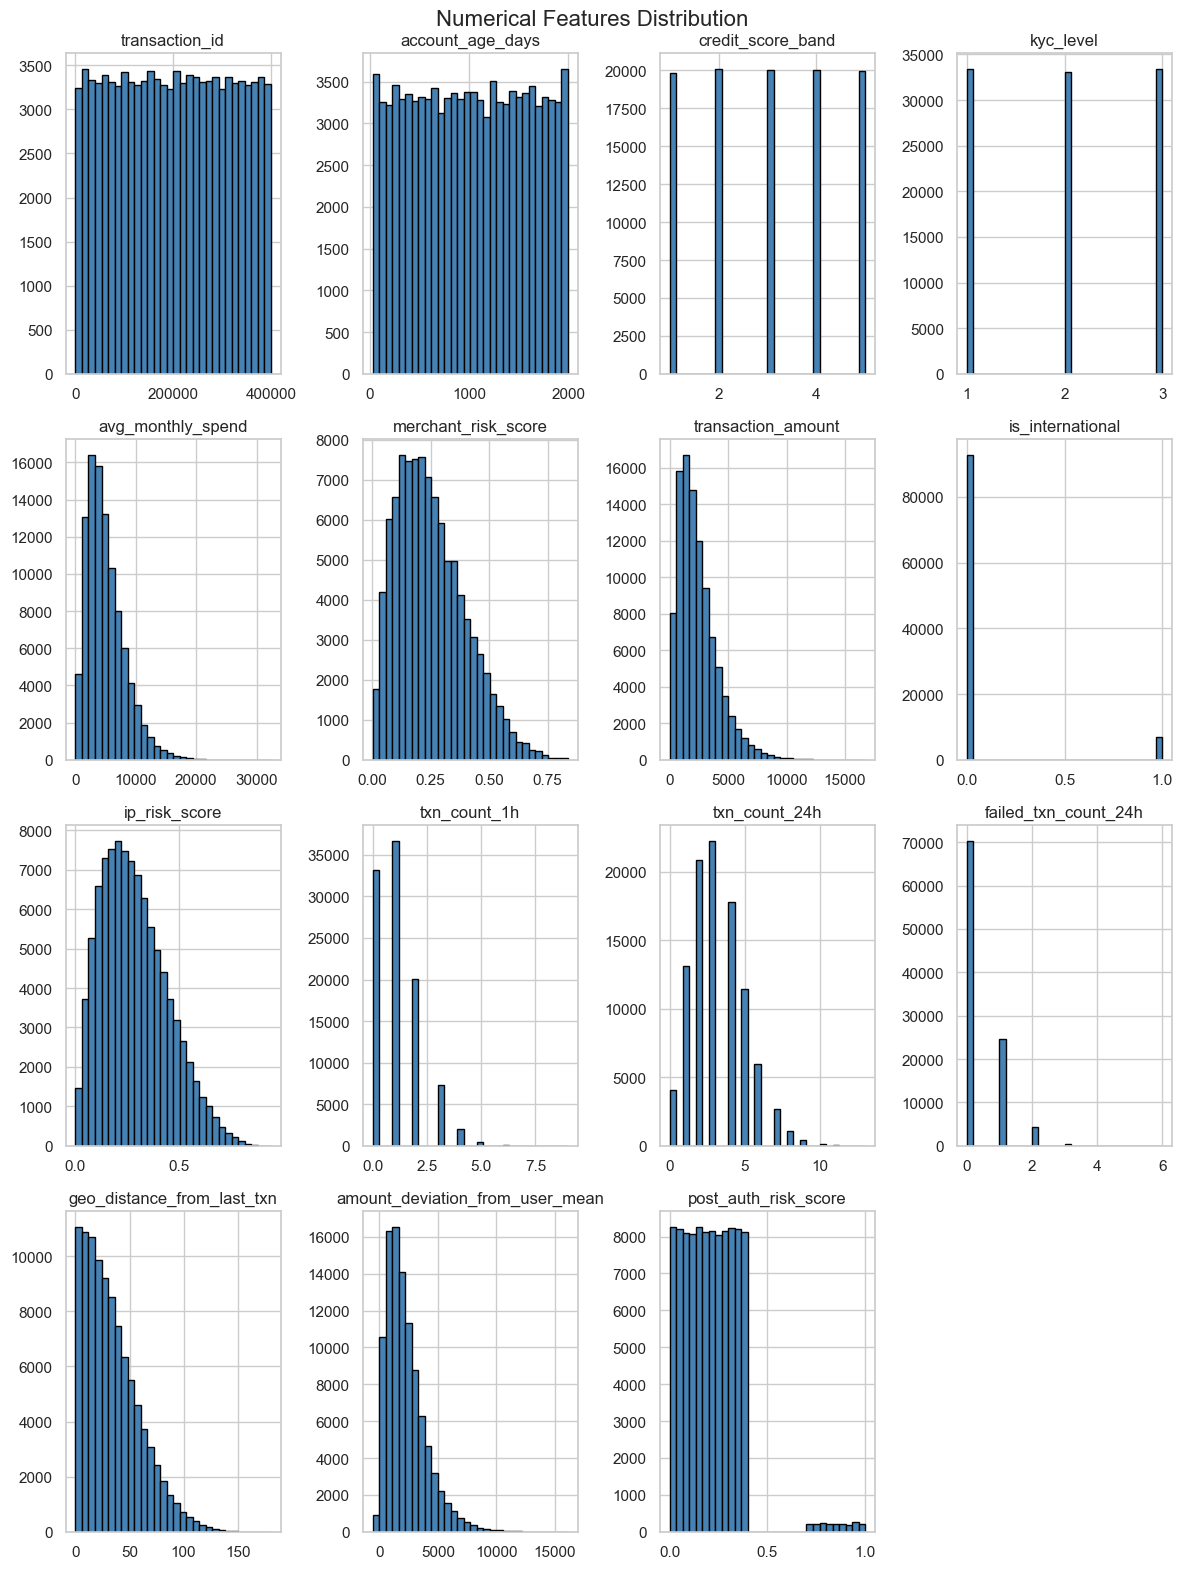

In [8]:
#---- Histogram for all numerical columns -----------------------------
num_cols = df.select_dtypes(include = ["int64", "float64"]).columns.tolist()
num_cols.remove("is_fraud")

df[num_cols].hist(bins = 30, figsize = (12, 16), color = "steelblue", edgecolor = "black")
plt.suptitle("Numerical Features Distribution", fontsize = 16)
plt.tight_layout()
plt.show()

## Outlier Detection
> Identifying extreme values in numerical columns

In [16]:
# ==============================================================
# Outlier Detection — IQR Method
# ==============================================================

num_cols = df.select_dtypes(include=["number"]).columns.tolist()

print(f"Checking outliers in {len(num_cols)} columns:\n")

total_outliers = 0

for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound   = Q1 - 1.5 * IQR
    upper_bound   = Q3 + 1.5 * IQR

    outlier_count  = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    outlier_pct    = outlier_count / len(df) * 100
    total_outliers += outlier_count

    print(f"  {col:40} Outliers: {outlier_count:5}  ({outlier_pct:.2f}%)")

# ── Total Summary ──────────────────────────────────────────────
total_pct = total_outliers / (len(df) * len(num_cols)) * 100

print(f"\n{'='*55}")
print(f"  Total Outliers : {total_outliers:,}")
print(f"  Total Rows     : {len(df):,}")
print(f"  Total Columns  : {len(num_cols)}")
print(f"  Overall %      : {total_pct:.2f}%")
print(f"{'='*55}")

Checking outliers in 16 columns:

  transaction_id                           Outliers:     0  (0.00%)
  account_age_days                         Outliers:     0  (0.00%)
  credit_score_band                        Outliers:     0  (0.00%)
  kyc_level                                Outliers:     0  (0.00%)
  avg_monthly_spend                        Outliers:  2507  (2.51%)
  merchant_risk_score                      Outliers:   836  (0.84%)
  transaction_amount                       Outliers:  3267  (3.27%)
  is_international                         Outliers:  7042  (7.05%)
  ip_risk_score                            Outliers:   615  (0.62%)
  txn_count_1h                             Outliers:   104  (0.10%)
  txn_count_24h                            Outliers:  1667  (1.67%)
  failed_txn_count_24h                     Outliers:   567  (0.57%)
  geo_distance_from_last_txn               Outliers:  1647  (1.65%)
  amount_deviation_from_user_mean          Outliers:  3269  (3.27%)
  is_fraud    

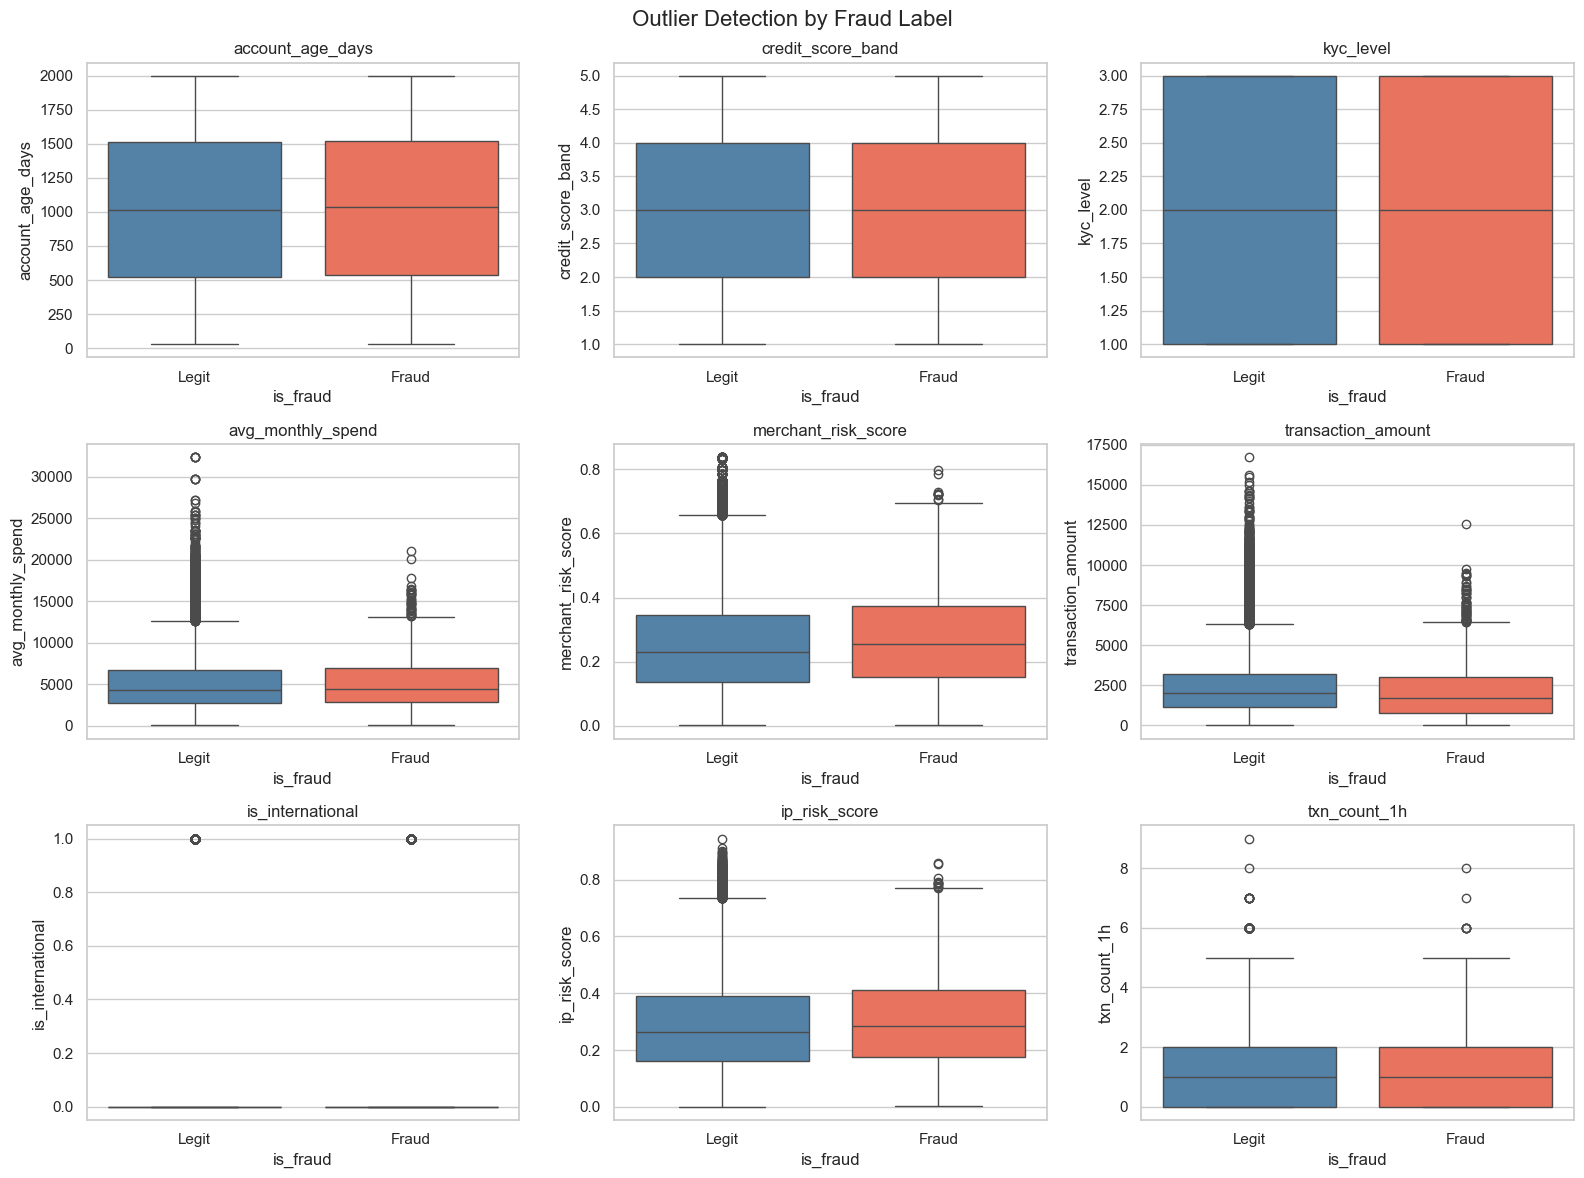

In [10]:
# ── Boxplots by Fraud Label ───────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols[:9]):
    sns.boxplot(
        x=df["is_fraud"], y=df[col],
        ax=axes[i],
        palette=["steelblue", "tomato"]
    )
    axes[i].set_title(col)
    axes[i].set_xticklabels(["Legit", "Fraud"])

plt.suptitle("Outlier Detection by Fraud Label", fontsize=16)  # fix typo
plt.tight_layout()
plt.show()

## Categorical Features Analysis
> Analyzing payment_channel, device_type, credit_score_band, kyc_level

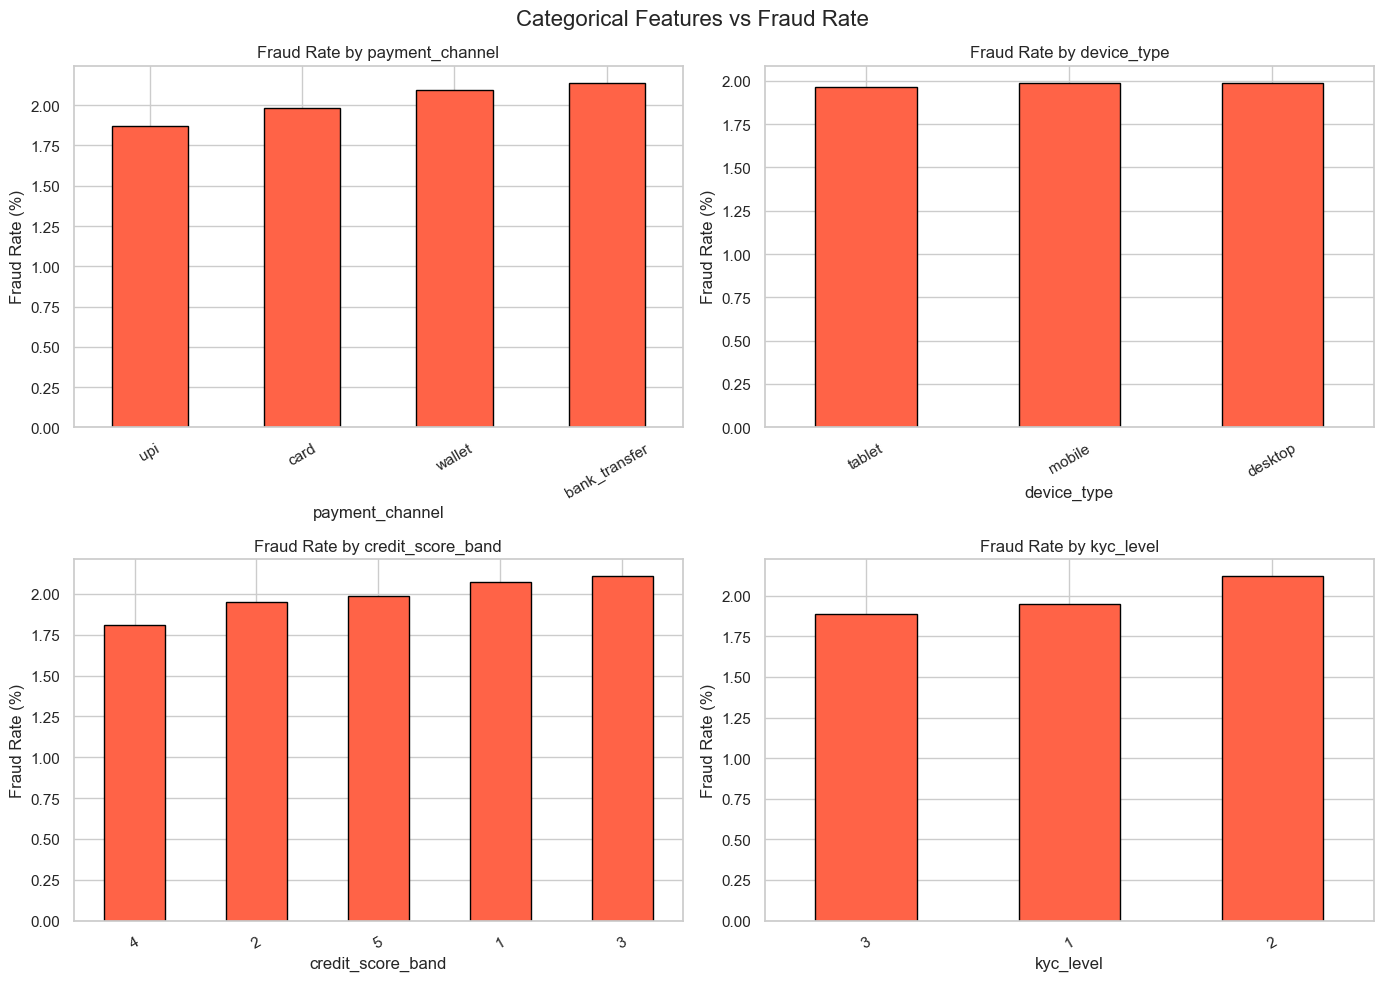

In [11]:
#---- Categorical columns vs Fraud rate --------------------------------
cat_cols = ["payment_channel", "device_type", "credit_score_band", "kyc_level"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    fraud_rate = df.groupby(col)["is_fraud"].mean()*100
    fraud_rate.sort_values().plot(kind="bar", ax = axes[i], color = "tomato", edgecolor = "black")
    axes[i].set_title(f"Fraud Rate by {col}")
    axes[i].set_ylabel("Fraud Rate (%)")
    axes[i].tick_params(axis="x", rotation=30)

plt.suptitle("Categorical Features vs Fraud Rate", fontsize = 16)
plt.tight_layout()
plt.show()

## Correlation Heatmap
> Which features are most correlated with fraud?

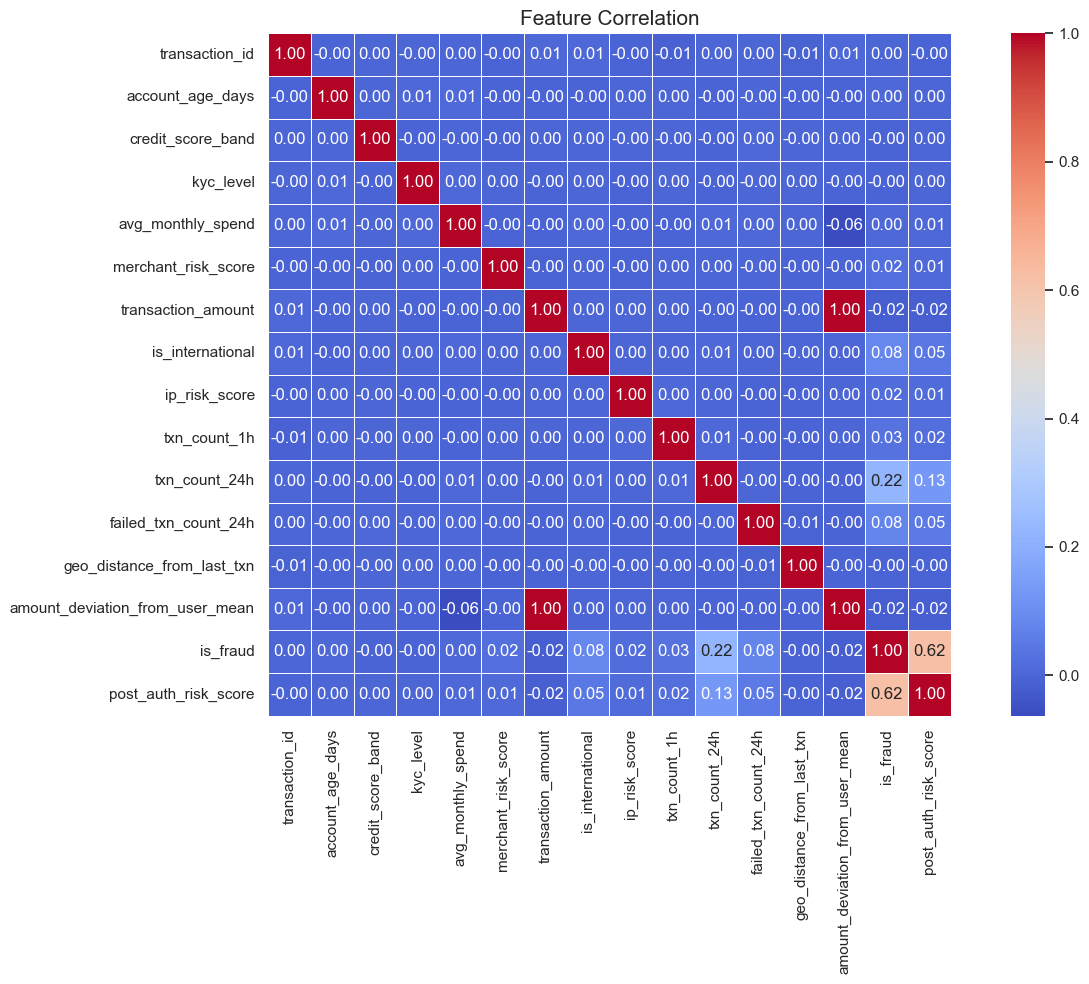

In [12]:
#---- Correlation Matrix ------------------------------------
plt.figure(figsize = (14, 10))
corr = df.select_dtypes(include = ["int64", "float64"]).corr()

sns.heatmap(corr, annot = True, fmt = ".2f", cmap = "coolwarm", linewidths = 0.5, square = True)
plt.title("Feature Correlation", fontsize = 15)
plt.tight_layout()
plt.show()

## Top Features Correlated with Fraud
> Which features have the strongest relationship with is_fraud?

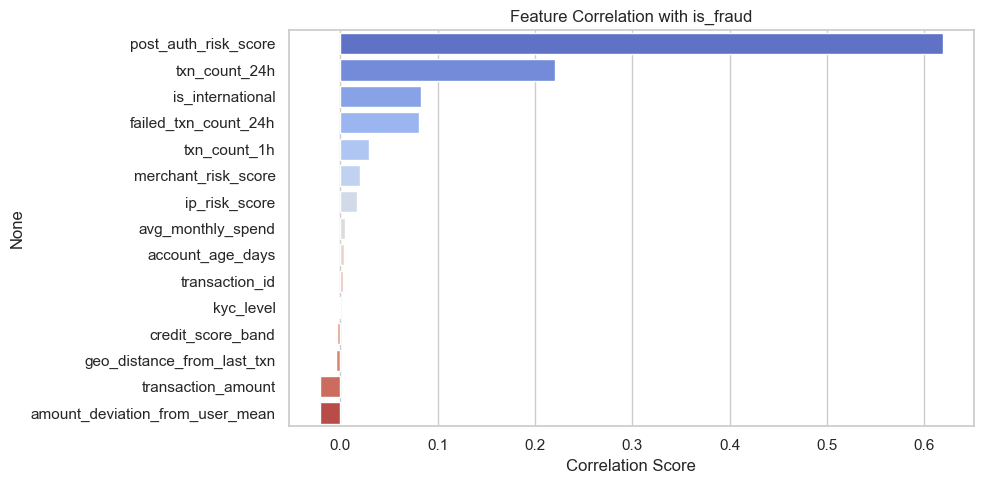

In [13]:
#---- Correlation with target ------------------------
corr_target = df.select_dtypes(include = ["float64", "int64"]).corr()["is_fraud"]
corr_target = corr_target.drop("is_fraud").sort_values(ascending = False)

sns.barplot(x=corr_target.values, y=corr_target.index, palette="coolwarm")
plt.title("Feature Correlation with is_fraud")
plt.xlabel("Correlation Score")
plt.tight_layout()
plt.show()